In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import torch
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('../')
from src.models.staged import STAGED
from src.utils.graph_constructor import GraphConstructor
from src.utils.simulated_data_processing import retrieve_simulated_data, retrieve_real_data

from src.utils.data_factory import create_oscillatory_dynamics_data
from src.utils.visualization import visualize_attention_graph, visualize_graph

In [2]:
cell_to_plot = 1 # index of the cell to plot

In [3]:
# data = retrieve_real_data(data_dir='../data/real')
# for key, value in data.items():
#     if isinstance(value, (torch.Tensor, np.ndarray)):
#         print(f"{key}: {value.shape}")
#     elif isinstance(value, (list, dict)):
#         print(f"{key}: length {len(value)}")
#     else:
#         print(f"{key}: {value}")

In [4]:
# data = retrieve_simulated_data(data_dir='../data/raw',sim_file='100_simulation_results.pkl')
# for key, value in data.items():
#     if isinstance(value, (torch.Tensor, np.ndarray)):
#         print(f"{key}: {value.shape}")
#     elif isinstance(value, (list, dict)):
#         print(f"{key}: length {len(value)}")
#     else:
#         print(f"{key}: {value}")

In [5]:
data = create_oscillatory_dynamics_data(
            n_time_points=25,
            n_cells=7,
            n_genes=6,
            dt=0.4,
            noise_level=0.05,
            device='cpu'
        )
for key, value in data.items():
    if isinstance(value, (torch.Tensor, np.ndarray)):
        print(f"{key}: {value.shape}")
    elif isinstance(value, (list, dict)):
        print(f"{key}: length {len(value)}")
    else:
        print(f"{key}: {value}")

gene_expression: torch.Size([25, 7, 6])
cell_positions: torch.Size([25, 7, 2])
genes: length 6
cell_type_assignments: torch.Size([7])
ligand_receptor_pairs: length 2
receptor_gene_pairs: length 4
prior_grns: length 2
n_time_points: 25
n_cells: 7
n_genes: 6
dt: 0.4
time_points: torch.Size([25])


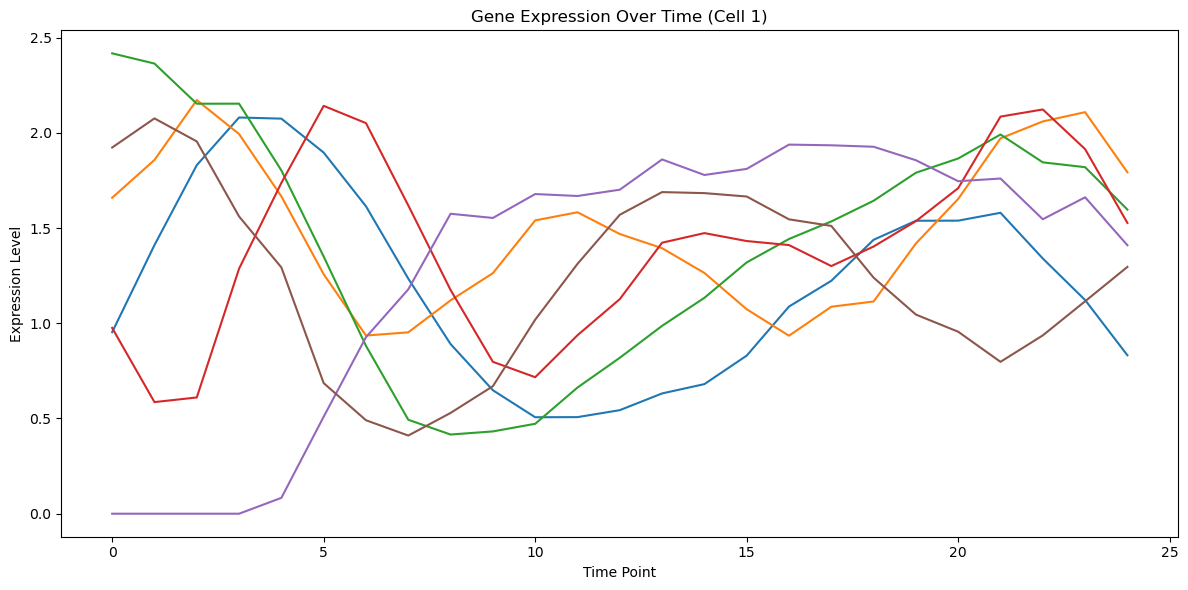

In [6]:
# Plot gene expression for all genes in all cells over time
gene_expression = data['gene_expression']  # shape: (n_time_points, n_cells, n_genes)
n_time_points, n_cells, n_genes = gene_expression.shape

plt.figure(figsize=(12, 6))
for gene_idx in range(n_genes):
    plt.plot(
        range(n_time_points),
        gene_expression[:, cell_to_plot, gene_idx].cpu().numpy(),
        label=f"{data['genes'][gene_idx]}"
    )
plt.xlabel("Time Point")
plt.ylabel("Expression Level")
plt.title(f"Gene Expression Over Time (Cell {cell_to_plot})")
# plt.legend(False)
plt.tight_layout()
plt.show()

In [7]:
import pickle
results_path = '../results/ode/rk4/predictions_0_10.pkl'
with open(results_path, 'rb') as f:
    
    infered_results = pickle.load(f)

In [8]:
infered_results['predictions'].shape[1]

7

In [9]:
infered_results.keys()

dict_keys(['predictions', 'gene_names', 'time_points', 'metadata'])

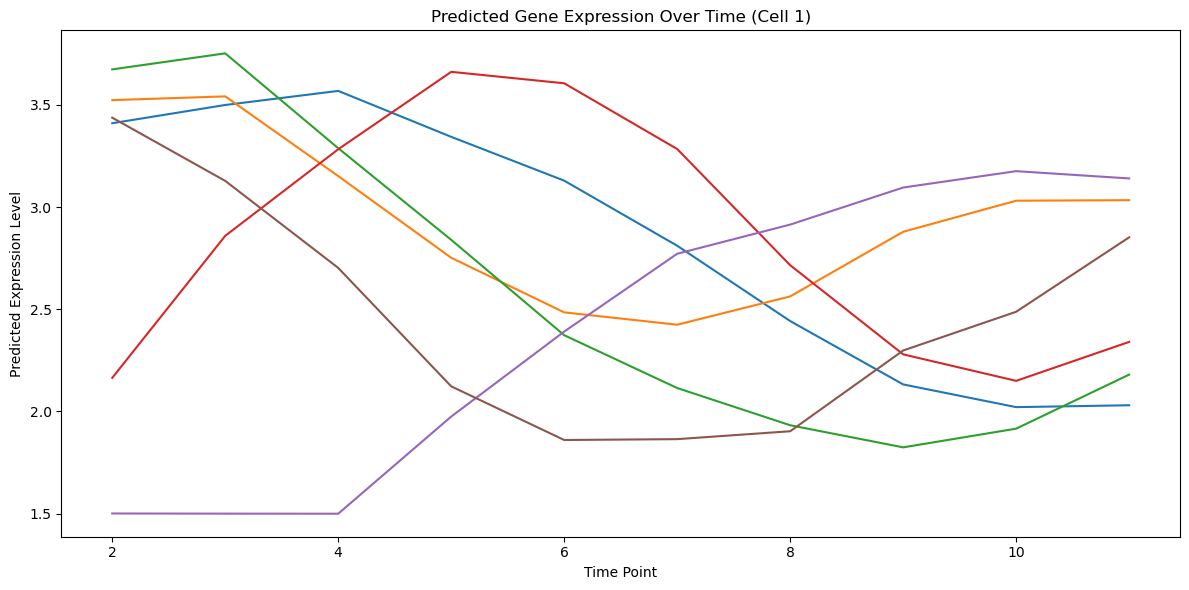

In [10]:
predictions = infered_results['predictions'] +1.5  # shape: (n_pred_time_points, n_cells, n_genes)
time_points = infered_results['time_points']
genes = infered_results['gene_names']
n_cells = predictions.shape[1]
plt.figure(figsize=(12, 6))
for gene_idx, gene_name in enumerate(genes):
    plt.plot(time_points, predictions[:, cell_to_plot, gene_idx], label=gene_name)
plt.xlabel("Time Point")
plt.ylabel("Predicted Expression Level")
plt.title(f"Predicted Gene Expression Over Time (Cell {cell_to_plot})")
# plt.legend()
plt.tight_layout()
plt.show()

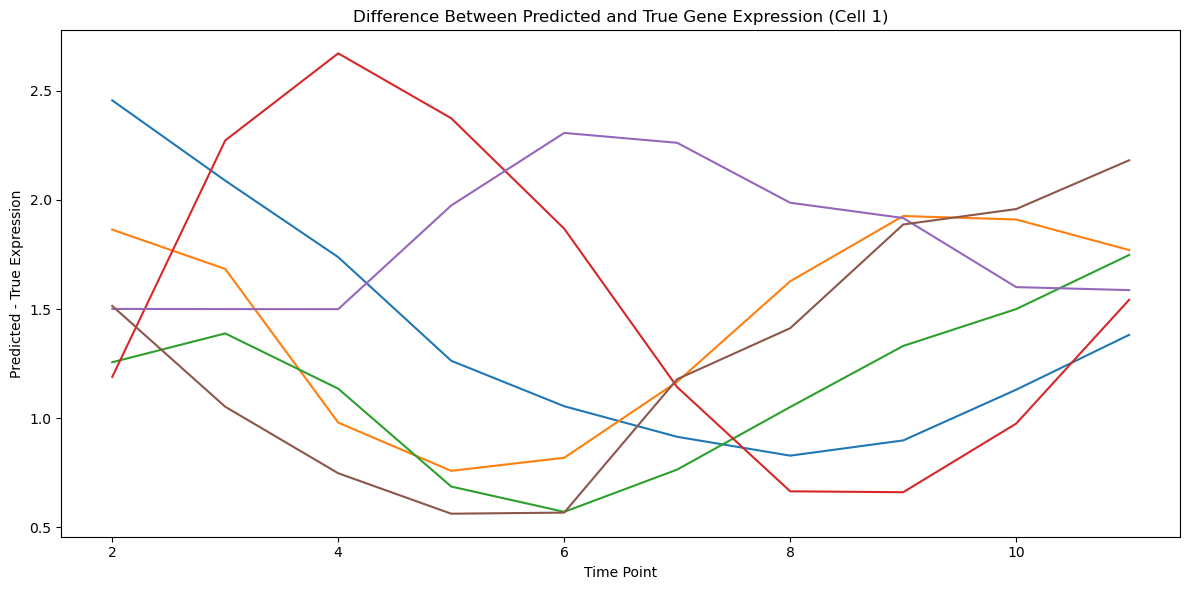

In [11]:
# Plot the difference between predicted and true gene expression for each gene in the selected cell
plt.figure(figsize=(12, 6))
for gene_idx, gene_name in enumerate(genes):
    # Ensure time alignment: predictions and true may have different time points
    min_len = min(len(time_points), n_time_points)
    diff = predictions[:min_len, cell_to_plot, gene_idx] - gene_expression[:min_len, cell_to_plot, gene_idx].cpu().numpy()
    plt.plot(time_points[:min_len], diff, label=gene_name)
plt.xlabel("Time Point")
plt.ylabel("Predicted - True Expression")
plt.title(f"Difference Between Predicted and True Gene Expression (Cell {cell_to_plot})")
# plt.legend()
plt.tight_layout()
plt.show()


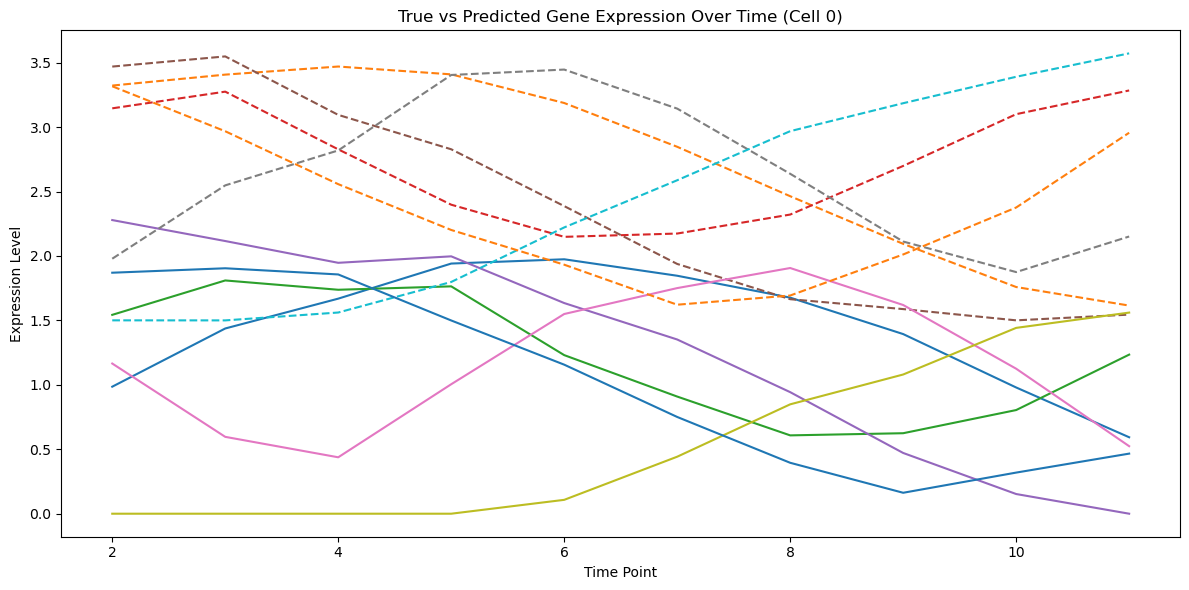

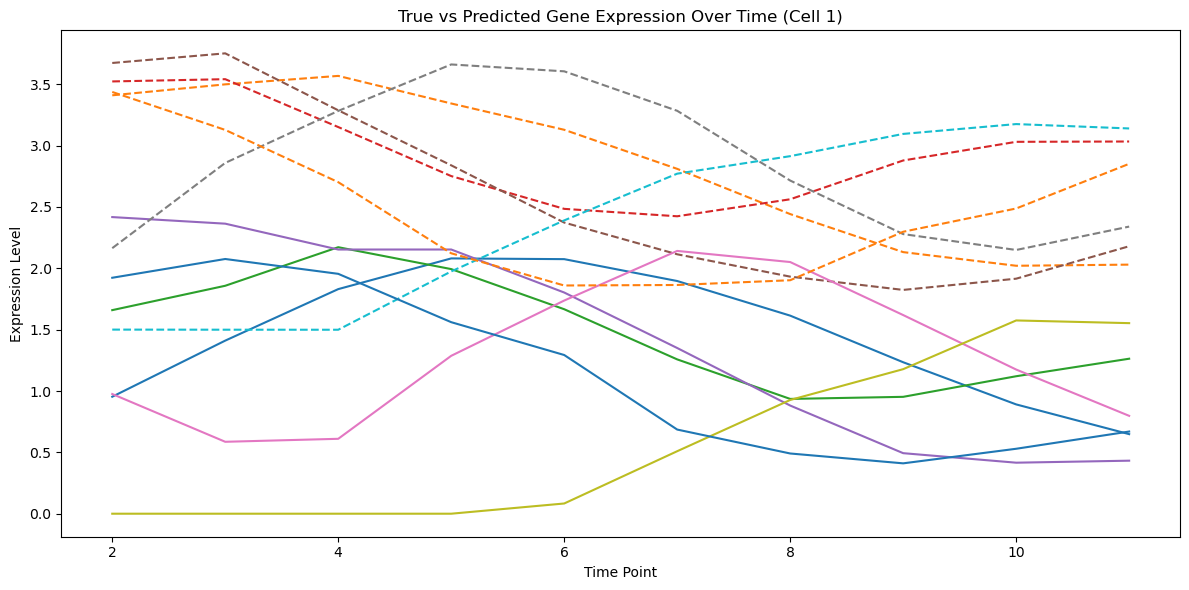

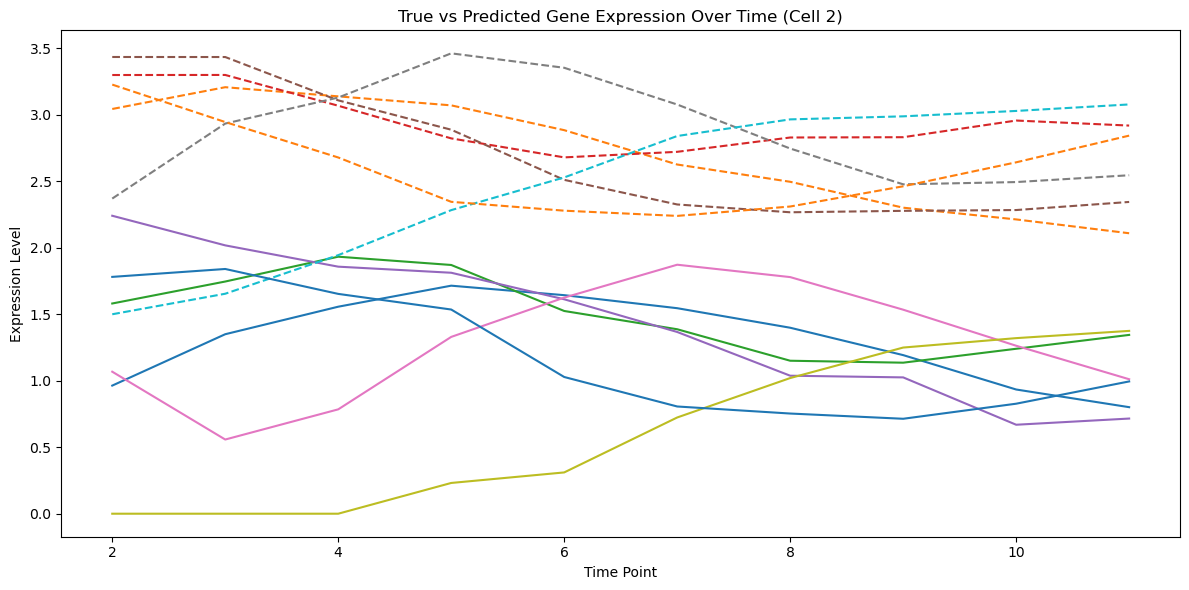

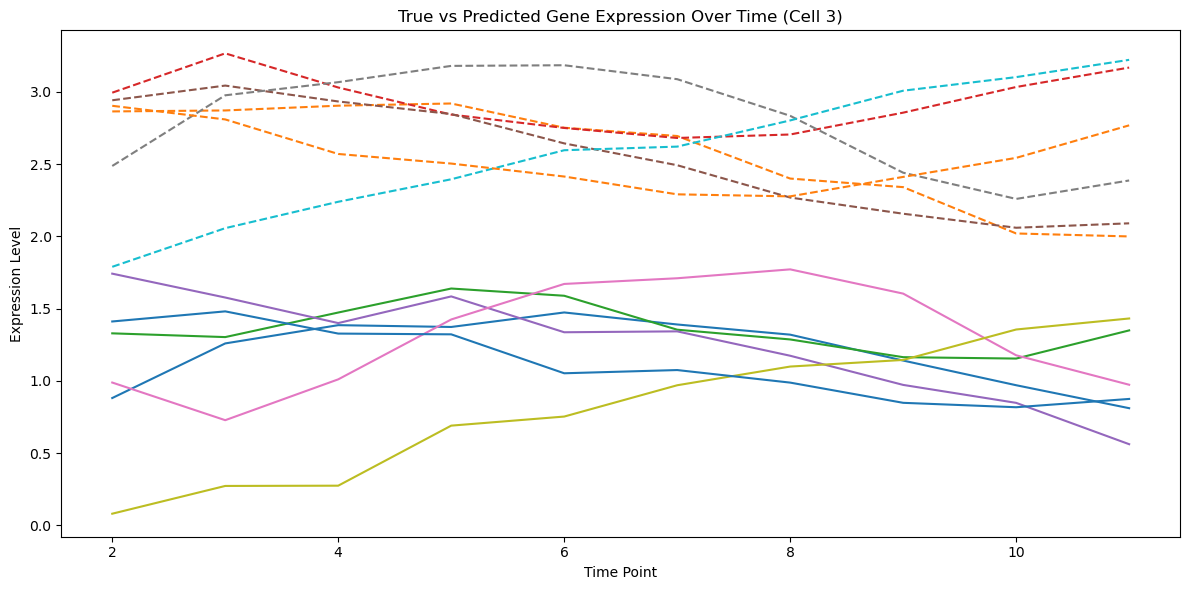

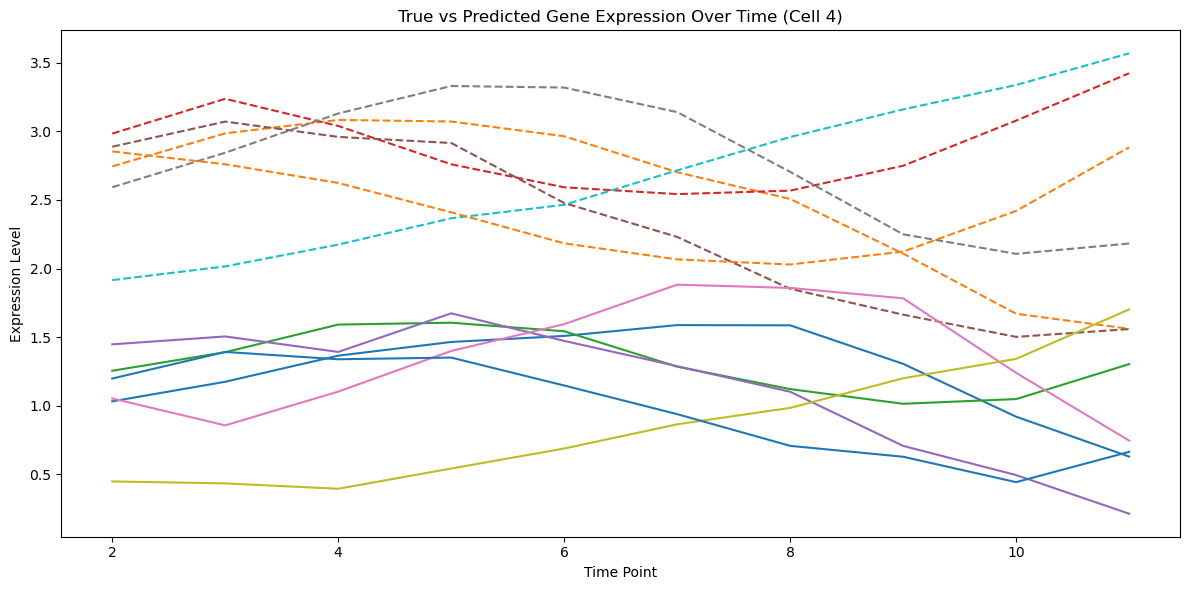

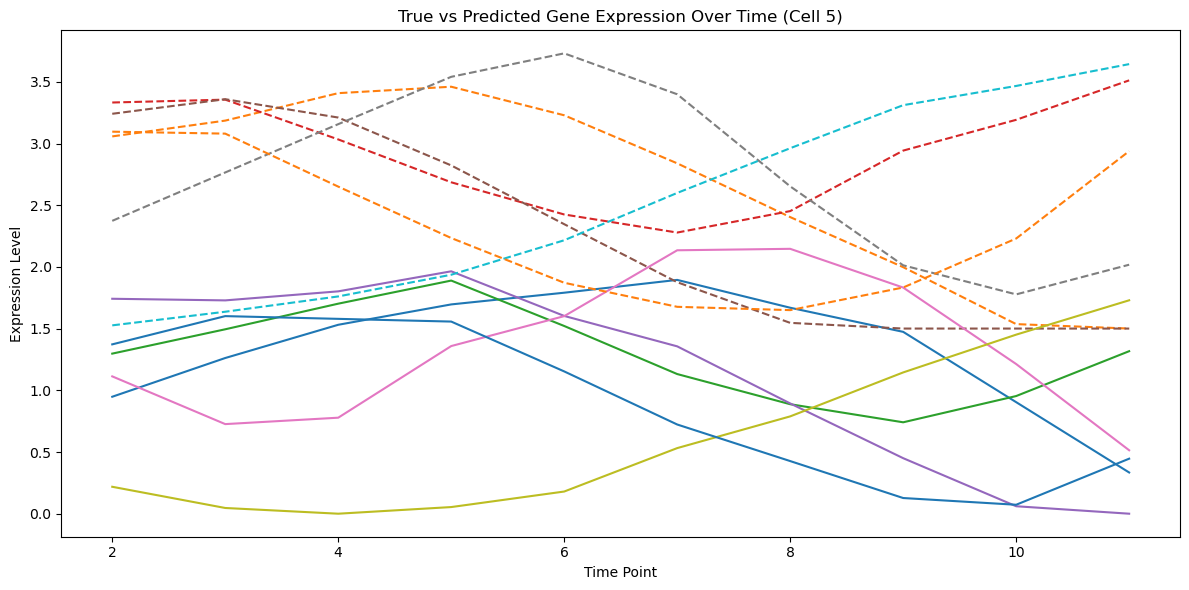

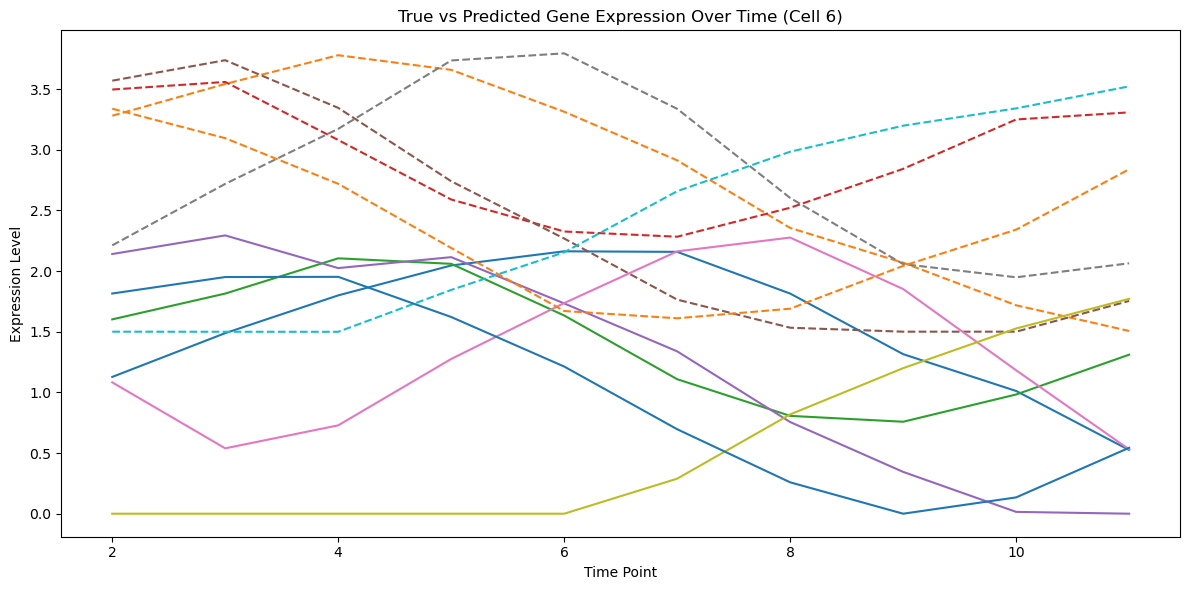

In [12]:
import os
cell_type = 0
output_dir = f'../inference_results/plots/{cell_type}'
os.makedirs(output_dir, exist_ok=True)

for cell_idx in range(n_cells):
    plt.figure(figsize=(12, 6))
    for idx, gene_name in enumerate(genes):
        # True gene expression (only plot for time points that match predictions)
        min_len = min(len(time_points), n_time_points)
        plt.plot(
            time_points[:min_len],
            gene_expression[:min_len, cell_idx, idx].cpu().numpy(),
            label=f"True {gene_name}"
        )
        # plt.plot(
        #     range(n_time_points),
        #     gene_expression[:, cell_idx, idx].cpu().numpy(),
        #     label=f"True {gene_name}"
        # )
        # Predicted gene expression
        plt.plot(
            time_points,
            predictions[:, cell_idx, idx],
            linestyle='--',
            label=f"Predicted {gene_name}"
        )
    plt.xlabel("Time Point")
    plt.ylabel("Expression Level")
    plt.title(f"True vs Predicted Gene Expression Over Time (Cell {cell_idx})")
    # plt.legend(False)
    plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, f'cell_{cell_idx}_gene_expression.png'))
    # plt.close()

In [13]:
infered_results.keys()

dict_keys(['predictions', 'gene_names', 'time_points', 'metadata'])

In [14]:
predictions.shape

(10, 7, 6)

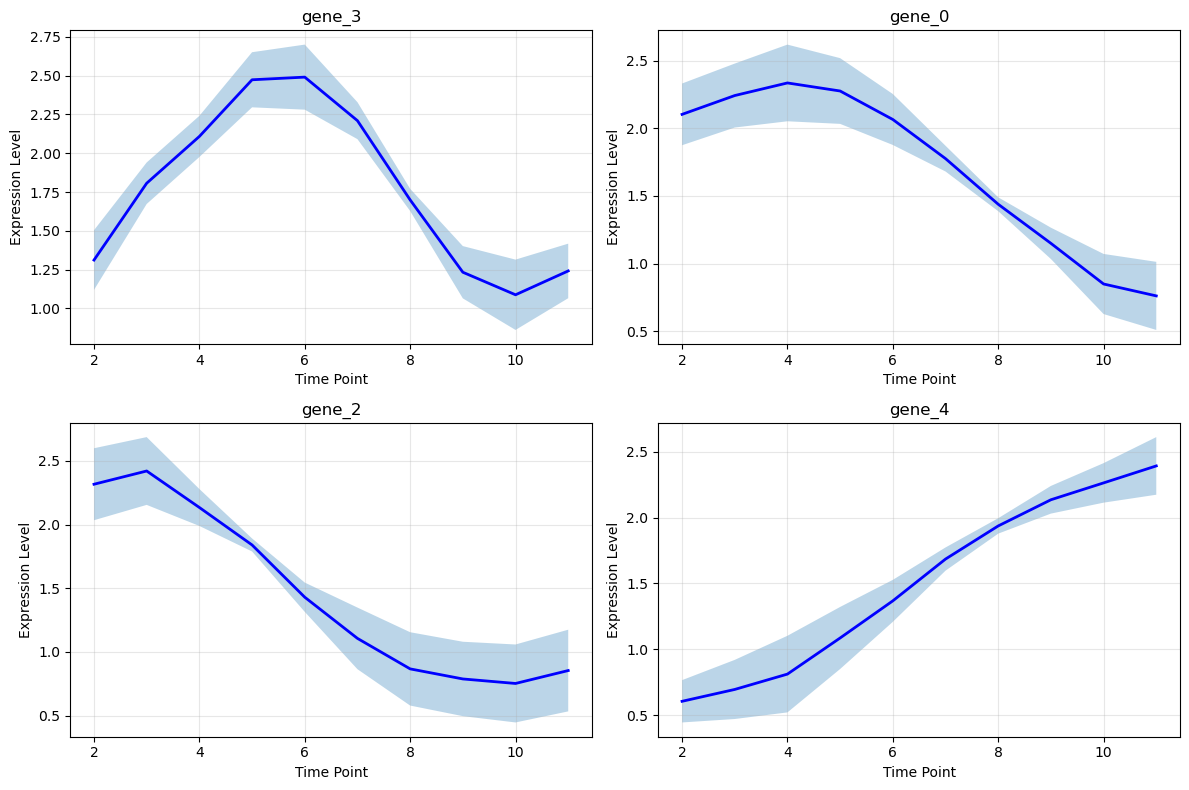

In [15]:

predictions = infered_results['predictions'] +.5 
time_points = infered_results['time_points']

# Plot gene expression trajectories for top varying genes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

mean_expr = np.mean(predictions, axis=1)  # Average across cells
gene_variance = np.var(mean_expr, axis=0)
top_genes = np.argsort(gene_variance)[-4:]  # Top 4 most variable genes

for i, gene_idx in enumerate(top_genes):
    ax = axes[i//2, i%2]
    ax.plot(time_points, mean_expr[:, gene_idx], 'b-', linewidth=2)
    ax.fill_between(
        time_points,
        mean_expr[:, gene_idx] - np.std(predictions[:, :, gene_idx], axis=1),
        mean_expr[:, gene_idx] + np.std(predictions[:, :, gene_idx], axis=1),
        alpha=0.3
    )
    ax.set_xlabel('Time Point')
    ax.set_ylabel('Expression Level')
    gene_name = infered_results['gene_names'][gene_idx] if infered_results['gene_names'] else f'Gene_{gene_idx}'
    ax.set_title(f'{gene_name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gene_trajectories.png'), dpi=300, bbox_inches='tight')
# plt.close()

# Create heatmap of expression changes
# fig, ax = plt.subplots(figsize=(12, 8))
# im = ax.imshow(mean_expr.T, aspect='auto', cmap='viridis')
# ax.set_xlabel('Time Point')
# ax.set_ylabel('Gene Index')
# ax.set_title(f'Gene Expression Heatmap - Cell Type {infered_results['cell_type_filter']}')
# plt.colorbar(im)
# plt.savefig(os.path.join(output_dir, 'expression_heatmap.png'), dpi=300, bbox_inches='tight')
# plt.close()

In [16]:
gene_expression.shape

torch.Size([25, 7, 6])

In [17]:
mean_expr

array([[2.103514  , 2.253658  , 2.3170269 , 1.311283  , 0.60481113,
        2.1676717 ],
       [2.242831  , 2.3621993 , 2.4211192 , 1.8066574 , 0.6948566 ,
        1.9695445 ],
       [2.3361154 , 2.0329509 , 2.1344235 , 2.1083527 , 0.8114375 ,
        1.6433295 ],
       [2.2764306 , 1.693108  , 1.8400018 , 2.4736779 , 1.0856751 ,
        1.2869617 ],
       [2.0656981 , 1.4867096 , 1.4295676 , 2.4907424 , 1.3676139 ,
        1.0303453 ],
       [1.776206  , 1.4436764 , 1.1060518 , 2.2099743 , 1.6849576 ,
        0.910214  ],
       [1.4384874 , 1.5659351 , 0.86646235, 1.6991892 , 1.9365412 ,
        0.936194  ],
       [1.1492814 , 1.8286499 , 0.78741306, 1.2327877 , 2.1353076 ,
        1.1691072 ],
       [0.8484748 , 2.091783  , 0.7518908 , 1.0874134 , 2.2633777 ,
        1.4345909 ],
       [0.7603764 , 2.235564  , 0.85342157, 1.2412274 , 2.3923802 ,
        1.868805  ]], dtype=float32)

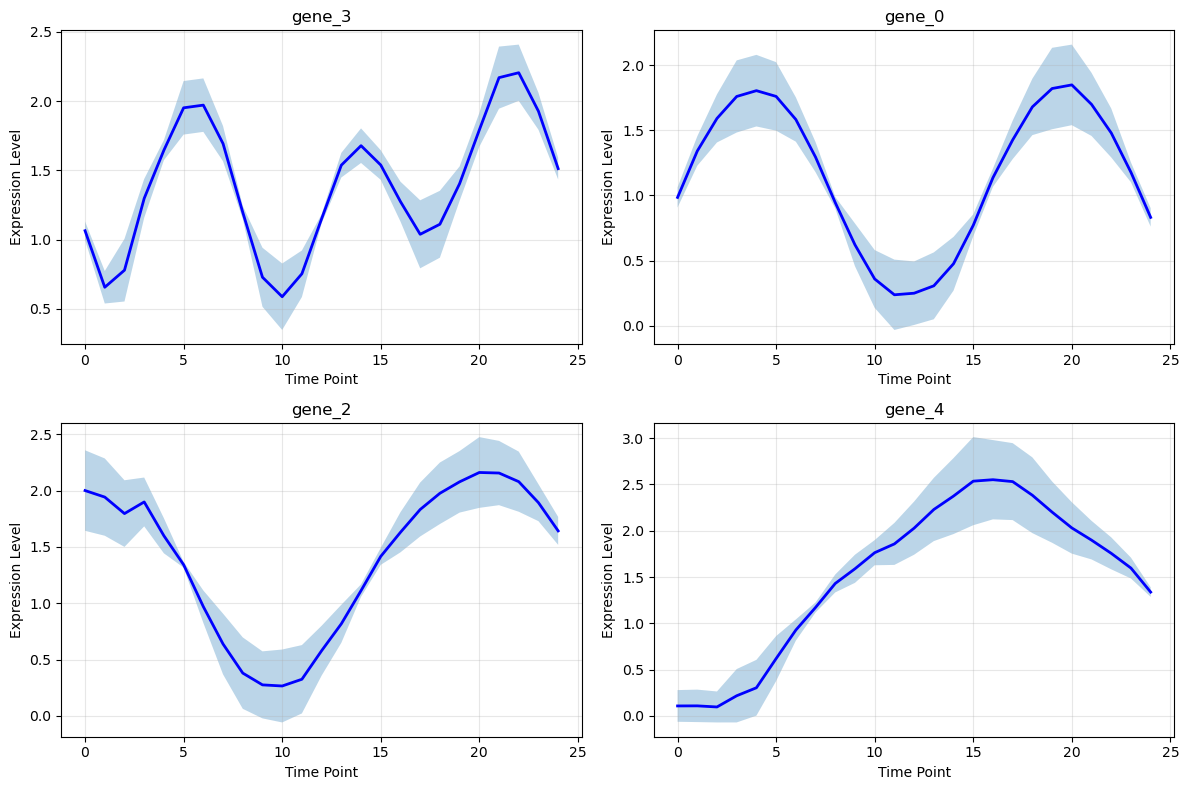

In [18]:
# Plot gene expression trajectories for top varying genes (true values)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Compute mean and std across cells for true gene expression
true_mean_expr = gene_expression.mean(dim=1).cpu().numpy()  # shape: (n_time_points, n_genes)
true_std_expr = gene_expression.std(dim=1).cpu().numpy()

for i, gene_idx in enumerate(top_genes):
    ax = axes[i//2, i%2]
    ax.plot(range(n_time_points), true_mean_expr[:, gene_idx], 'b-', linewidth=2)
    ax.fill_between(
        range(n_time_points),
        true_mean_expr[:, gene_idx] - true_std_expr[:, gene_idx],
        true_mean_expr[:, gene_idx] + true_std_expr[:, gene_idx],
        alpha=0.3
    )
    ax.set_xlabel('Time Point')
    ax.set_ylabel('Expression Level')
    gene_name = genes[gene_idx] if genes else f'Gene_{gene_idx}'
    ax.set_title(f'{gene_name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gene_trajectories_true.png'), dpi=300, bbox_inches='tight')


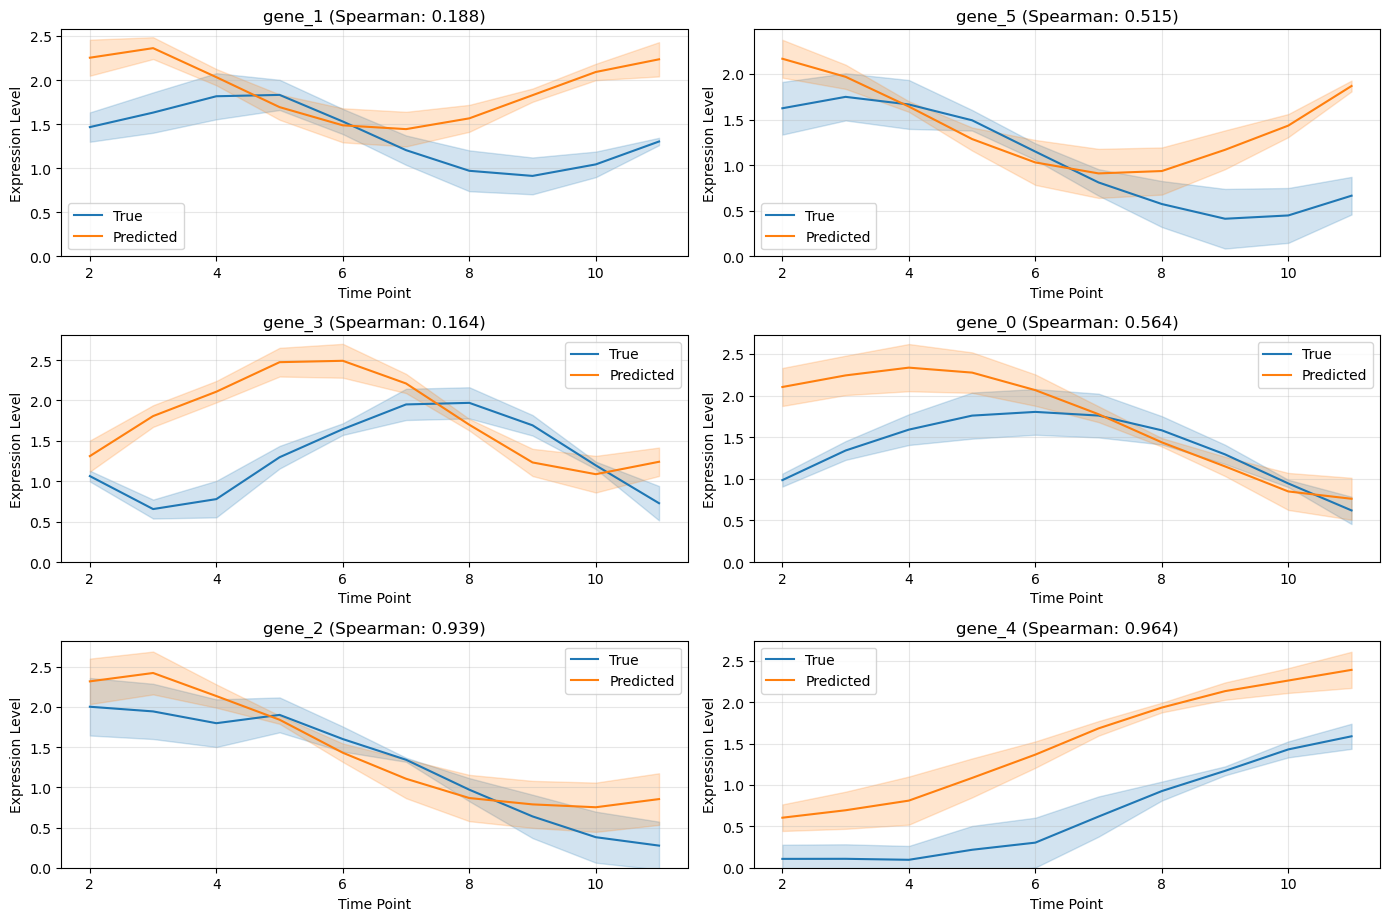

In [19]:
# Overlay true and predicted gene expression trajectories for top n_genes varying genes
n_genes = 10
top_n_genes = np.argsort(gene_variance)[-n_genes:]  # Top n_genes most variable genes

# Calculate the maximum expression level across all genes for consistent y-axis scaling
max_expression = 0
for gene_idx in top_n_genes:
    # Maximum from true values (with confidence intervals)
    true_upper = true_mean_expr[:len(time_points), gene_idx] + true_std_expr[:len(time_points), gene_idx]
    max_true = np.max(true_upper)
    
    # Maximum from predicted values (with confidence intervals)
    pred_upper = mean_expr[:, gene_idx] + np.std(predictions[:, :, gene_idx], axis=1)
    max_pred = np.max(pred_upper)
    
    # Update global maximum
    max_expression = max(max_expression, max_true, max_pred)

n_rows = n_genes // 2 + n_genes % 2
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for i, gene_idx in enumerate(top_n_genes):
    ax = axes[i]
    # True values (aligned to prediction time points)
    ax.plot(
        time_points,
        true_mean_expr[:len(time_points), gene_idx],
        color='tab:blue',
        label='True'
    )
    ax.fill_between(
        time_points,
        true_mean_expr[:len(time_points), gene_idx] - true_std_expr[:len(time_points), gene_idx],
        true_mean_expr[:len(time_points), gene_idx] + true_std_expr[:len(time_points), gene_idx],
        color='tab:blue',
        alpha=0.2
    )
    # Predicted values
    ax.plot(
        time_points,
        mean_expr[:, gene_idx],
        color='tab:orange',
        label='Predicted'
    )
    ax.fill_between(
        time_points,
        mean_expr[:, gene_idx] - np.std(predictions[:, :, gene_idx], axis=1),
        mean_expr[:, gene_idx] + np.std(predictions[:, :, gene_idx], axis=1),
        color='tab:orange',
        alpha=0.2
    )
    ax.set_xlabel('Time Point')
    ax.set_ylabel('Expression Level')
    gene_name = genes[gene_idx] if genes else f'Gene_{gene_idx}'
    
    # Calculate Spearman correlation between true and predicted values
    from scipy.stats import spearmanr
    correlation, _ = spearmanr(true_mean_expr[:len(time_points), gene_idx], mean_expr[:, gene_idx])
    
    ax.set_title(f'{gene_name} (Spearman: {correlation:.3f})')
    ax.grid(True, alpha=0.3)
    ax.legend()
    # Set y-axis limits using the calculated maximum across all plots
    # ax.set_ylim(0, max_expression * 1.05)  # Add 5% padding for better visualization
    ax.set_ylim(0)  # Add 5% padding for better visualization


# Hide unused subplots if any
for i in range(len(top_n_genes), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'gene_trajectories_overlay_top{n_genes}.png'), dpi=300, bbox_inches='tight')
plt.show()

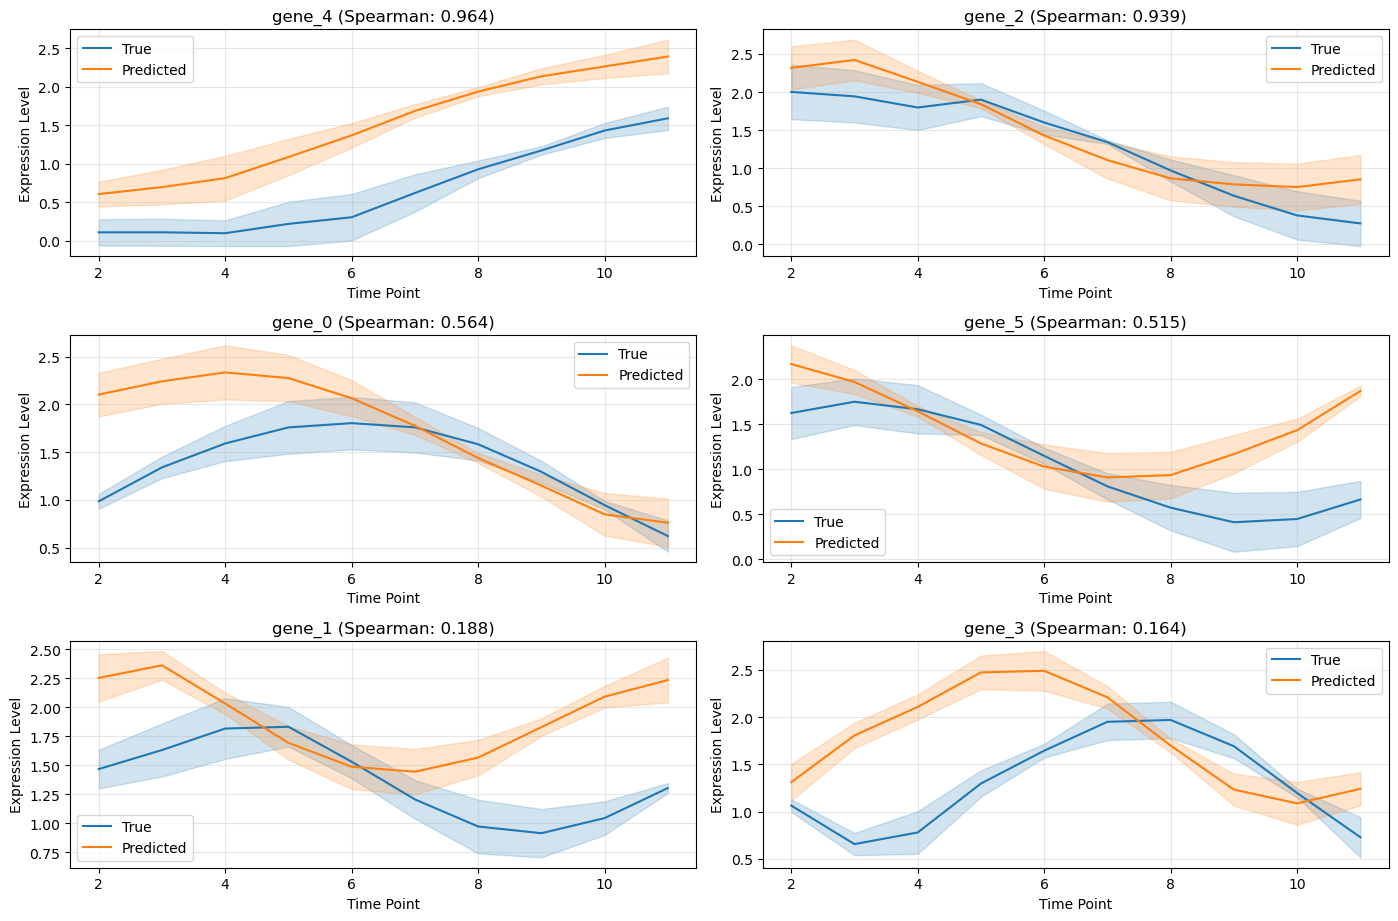

In [20]:
# Overlay true and predicted gene expression trajectories for top n_genes varying genes
n_genes = 10
top_variable_genes = np.argsort(gene_variance)[-n_genes:]  # Top n_genes most variable genes

# Calculate Spearman correlation for each gene and sort by correlation
from scipy.stats import spearmanr
gene_correlations = []
for gene_idx in top_variable_genes:
    correlation, _ = spearmanr(true_mean_expr[:len(time_points), gene_idx], mean_expr[:, gene_idx])
    gene_correlations.append((gene_idx, correlation))

# Sort genes by Spearman correlation (best to worst)
gene_correlations.sort(key=lambda x: x[1], reverse=True)
top_n_genes = [gene_idx for gene_idx, _ in gene_correlations]

# Calculate the maximum expression level across all genes for consistent y-axis scaling
max_expression = 0
for gene_idx in top_n_genes:
    # Maximum from true values (with confidence intervals)
    true_upper = true_mean_expr[:len(time_points), gene_idx] + true_std_expr[:len(time_points), gene_idx]
    max_true = np.max(true_upper)
    
    # Maximum from predicted values (with confidence intervals)
    pred_upper = mean_expr[:, gene_idx] + np.std(predictions[:, :, gene_idx], axis=1)
    max_pred = np.max(pred_upper)
    
    # Update global maximum
    max_expression = max(max_expression, max_true, max_pred)

n_rows = n_genes // 2 + n_genes % 2
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for i, gene_idx in enumerate(top_n_genes):
    ax = axes[i]
    # True values (aligned to prediction time points)
    ax.plot(
        time_points,
        true_mean_expr[:len(time_points), gene_idx],
        color='tab:blue',
        label='True'
    )
    ax.fill_between(
        time_points,
        true_mean_expr[:len(time_points), gene_idx] - true_std_expr[:len(time_points), gene_idx],
        true_mean_expr[:len(time_points), gene_idx] + true_std_expr[:len(time_points), gene_idx],
        color='tab:blue',
        alpha=0.2
    )
    # Predicted values
    ax.plot(
        time_points,
        mean_expr[:, gene_idx],
        color='tab:orange',
        label='Predicted'
    )
    ax.fill_between(
        time_points,
        mean_expr[:, gene_idx] - np.std(predictions[:, :, gene_idx], axis=1),
        mean_expr[:, gene_idx] + np.std(predictions[:, :, gene_idx], axis=1),
        color='tab:orange',
        alpha=0.2
    )
    ax.set_xlabel('Time Point')
    ax.set_ylabel('Expression Level')
    gene_name = genes[gene_idx] if genes else f'Gene_{gene_idx}'
    
    # Calculate Spearman correlation between true and predicted values
    correlation = gene_correlations[i][1]  # Use pre-calculated correlation
    
    ax.set_title(f'{gene_name} (Spearman: {correlation:.3f})')
    ax.grid(True, alpha=0.3)
    ax.legend()
    # Set y-axis limits using the calculated maximum across all plots
    # ax.set_ylim(0, max_expression * 1.05)  # Add 5% padding for better visualization

# Hide unused subplots if any
for i in range(len(top_n_genes), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'gene_trajectories_overlay_top{n_genes}.png'), dpi=300, bbox_inches='tight')
plt.show()